<a href="https://colab.research.google.com/github/elenahudg/EMSC2010-W10-Group-Project/blob/main/EMSC2010_W10_Group_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name: Cloudy with a Chance of Stats

Project week: 10

Project title: The Effect of the Sun & Moon on Tide Patterns

Datasets used (name and source):

University of Hawaii Sea Center Longterm Tidal Data. Retrieved from: https://uhslc.soest.hawaii.edu/data/

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Elena | Sameer | Yes| Add note|
| Data steward | Sameer | Sutton | Yes| Add note|
| Analysis / modelling | Sutton | Kimi | Yes| Add note|
| Visualisation / interpretation | Kimi | Cathy | Yes| Add note|
| Narrative | Cathy | Leo | Yes| Add note|
| Quality Control / Reproducibility  | Leo | Elena | Yes| Add note|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

**Project Overview**




Time series analysis was used to identify signals that can be emerged from tide gauge data in Brest, France. These signals included the monthly lunar cycle, the 18.6 year lunar nodal cycle, the 11 year solar cycle, and the 93 year solar tidal cycle. The data was plotted and its frequency spectrum was able to be calculated. Frequencies of the signals were isolated to determine which frequency aligns best with this long term tide behaviour.

**Data Import**

As the data steward for this project, a significant portion of my initial efforts involved an extensive search for appropriate datasets to facilitate a robust Fourier series analysis of tidal fluctuations. This process required sifting through various data repositories and portals to find historical sea-level measurements that met our criteria for both temporal depth and data quality.

After considerable exploration, the University of Hawaii Sea Level Center (UHSLC) portal (`https://uhslc.soest.hawaii.edu/data/`) emerged as an invaluable resource. Its comprehensive collection of long-term tidal gauge records proved ideal. The decision to focus on Brest, France, was driven by a crucial factor: the availability of continuous data spanning from 1846 to the present. This exceptionally long time series is paramount for a meaningful Fourier analysis, allowing us to identify subtle, long-period tidal constituents and assess changes in fluctuation patterns over nearly two centuries. Ensuring the integrity and consistency of this historical data, including handling any potential gaps or inconsistencies in the original raw files, was a primary responsibility during the import phase.

In [ ]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# This cell defines variables for the Excel spreadsheet and sheet names.
# These variables will be used later to import data from the specified sheets.
spreadsheet_name = 'Sea_Level_Brest_France.xlsx' # Name of the Excel file containing the sea level data.
Sheet1 = 'd822 (1)' # Name of the worksheet containing the data.

In [ ]:
Brest_df = pd.read_excel(
    spreadsheet_name, # Pass the variable holding the Excel file name to `read_excel`.
    sheet_name='d822 (1)', # Specify the sheet named 'Sheet1' to read data for Brest,France
    skiprows=0      # Skip the first row, as it contains headers that are not part of the data.
)
Brest_df.head() # Display the first few rows of the created DataFrame to verify data loading and structure.

,Year,Month,Day,Sea Level(mm)
0,1846,1,4,3830
1,1846,1,5,3749
2,1846,1,6,3856
3,1846,1,7,3841
4,1846,1,8,3760


**Modelling & Analysis**

Sutton defined the frequency spectrum to calculate the frequency spectrum for each signal. This was then followed by defining the lowpass, highpass, and bandpass filters in which they can be used in later analysis to isolate frequencies.

In [ ]:
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals   = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def bandpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff[0]] = 0.0 #cycles below cutoff[0] are given an amplitude of 0
  fft_vals[freqs>cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

The tide gauge data was cleaned, which involved replacing missing data with NaN so the data can be plotted properly. A trendline was fitted onto the graph, indicating a decreaseing sea level over time.

In [ ]:
Brest_df['Date'] = pd.to_datetime(Brest_df[['Year', 'Month', 'Day']], errors='coerce')

# Replace the placeholder for missing data (-32767) with NaN
Brest_df.replace(-32767, np.nan, inplace=True)

# Fill missing values using linear interpolation, which is suitable for time series data
# Ensure that the 'Sea Level(mm)' column is numeric before interpolation
Brest_df['Sea Level(mm)'] = pd.to_numeric(Brest_df['Sea Level(mm)'], errors='coerce')
Brest_df['Sea Level(mm)'].interpolate(method='linear', inplace=True)

# Drop rows where 'Date' could not be coerced (e.g., invalid month/day combinations)
Brest_df.dropna(subset=['Date'], inplace=True)

# Set the 'Date' column as the DataFrame index
Brest_df.set_index('Date', inplace=True)

# Display the first few rows of the cleaned DataFrame
display(Brest_df.head())

/tmp/ipykernel_7305/3542807649.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Brest_df['Sea Level(mm)'].interpolate(method='linear', inplace=True)


,Year,Month,Day,Sea Level(mm)
Date,,,,
1846-01-04,1846,1,4,3830.0
1846-01-05,1846,1,5,3749.0
1846-01-06,1846,1,6,3856.0
1846-01-07,1846,1,7,3841.0
1846-01-08,1846,1,8,3760.0


In [ ]:
time_numeric = (Brest_df.index - Brest_df.index.min()).days
signal = Brest_df['Sea Level(mm)'].values

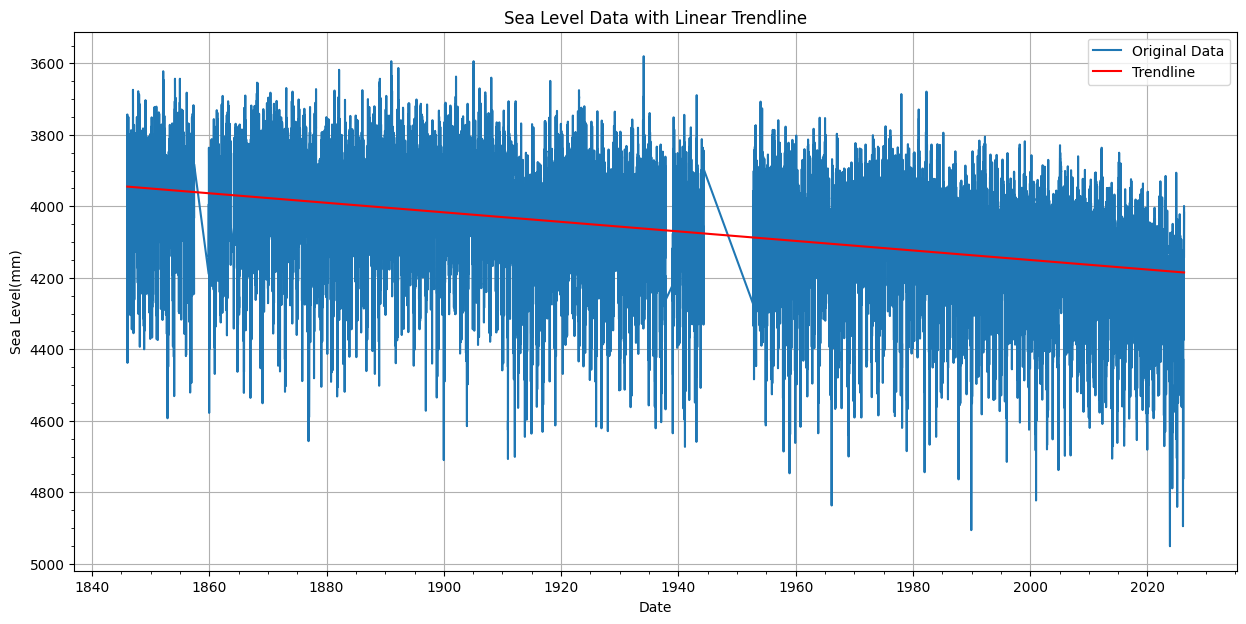

In [ ]:
pp = np.polyfit(time_numeric, Brest_df['Sea Level(mm)'].values, 1) #fit a trendline to the data

plt.figure(figsize=(15, 7))
plt.plot(Brest_df.index, Brest_df['Sea Level(mm)'], label='Original Data') #plot the original data
plt.plot(Brest_df.index, np.polyval(pp, time_numeric), 'r', label='Trendline') #plot the trendline
plt.xlabel('Date') #label the x-axis
plt.ylabel(r'Sea Level(mm)') #label the y-axis
plt.title('Sea Level Data with Linear Trendline') # Add a title for clarity
plt.gca().invert_yaxis() #invert the y-axis
plt.minorticks_on() #add minorticks
plt.grid(True) # Add grid for better readability
plt.legend() # Add legend
plt.show() # Display the plot

Sutton then calculated and plotted the sea level frequency spectrum. This result produced a couple of notable peaks in frequency with high amplitudes that can be investigated.

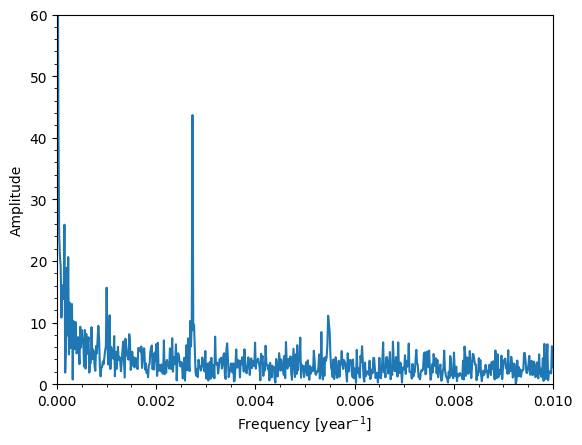

In [ ]:
freqs, amps = freq_spectrum(time_numeric, signal) #calculate the frequency spectrum
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [year$^{-1}$]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.xlim([0,.01]) #limits the x-axis
plt.ylim([0,60]) #limits the y-axis
plt.minorticks_on() #add minorticks

Frequency for monthly lunar cycle, 18.6 year lunar nodal cycle, 11 year solar cycle, and the 93 year solar tidal cycle was defined and plotted on the detrended signal.

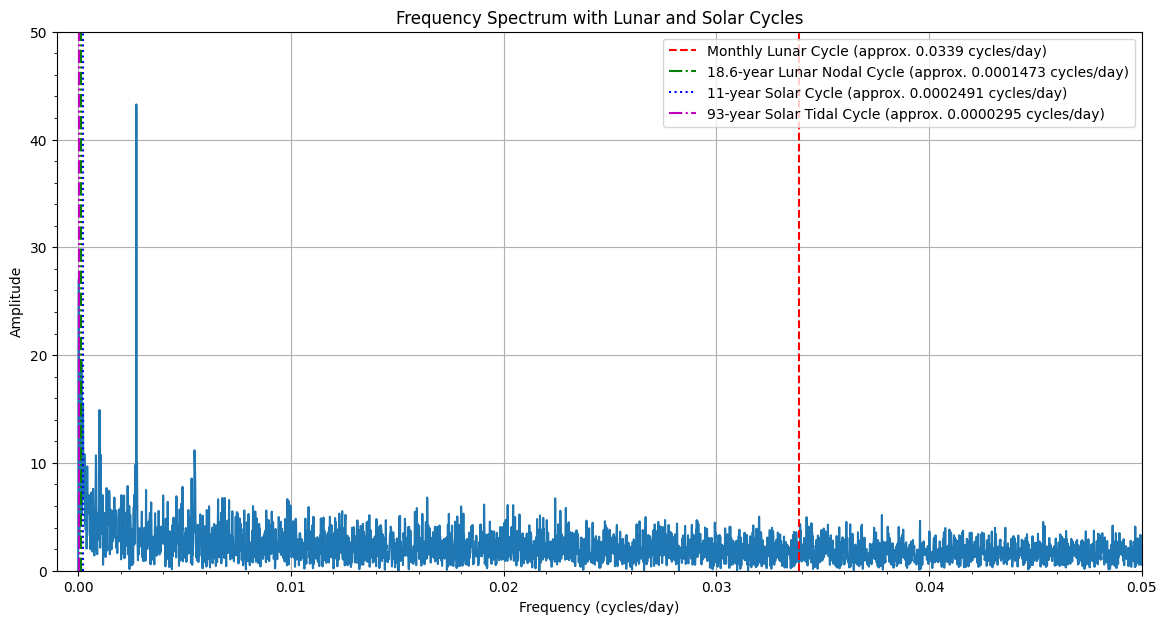

In [ ]:
lunar_cycle_freq = 1 / 29.53 # cycles per day for the monthly lunar cycle
lunar_nodal_freq = 1 / (18.6 * 365) # cycles per day for the 18.6-year lunar nodal cycle
solar_11yr_freq = 1 / (11 * 365) # cycles per day for the 11-year solar cycle
solar_93yr_freq = 1 / (93 * 365) # cycles per day for the 93-year solar tidal cycle

# Recalculate freqs and amps from the detrended signal
detrend = signal - np.polyval(pp, time_numeric)
freqs, amps = freq_spectrum(time_numeric, detrend)

plt.figure(figsize=(14, 7))
plt.plot(freqs, amps) # Plot the frequency spectrum of the detrended data

plt.xlabel('Frequency (cycles/day)')
plt.ylabel('Amplitude')
plt.title('Frequency Spectrum with Lunar and Solar Cycles')
plt.xlim([-0.001, 0.05]) # Adjust x-axis to clearly see the monthly lunar cycle and show the nodal/solar cycles close to zero
plt.ylim([0, 50]) # Adjusted y-axis for better visualization

# Mark the monthly lunar cycle
plt.axvline(x=lunar_cycle_freq, color='r', linestyle='--', label=f'Monthly Lunar Cycle (approx. {lunar_cycle_freq:.4f} cycles/day)')

# Mark the lunar nodal cycle
plt.axvline(x=lunar_nodal_freq, color='g', linestyle='-.', label=f'18.6-year Lunar Nodal Cycle (approx. {lunar_nodal_freq:.7f} cycles/day)')

# Mark the 11-year solar cycle
plt.axvline(x=solar_11yr_freq, color='b', linestyle=':', label=f'11-year Solar Cycle (approx. {solar_11yr_freq:.7f} cycles/day)')

# Mark the 93-year solar tidal cycle
plt.axvline(x=solar_93yr_freq, color='m', linestyle='-.', label=f'93-year Solar Tidal Cycle (approx. {solar_93yr_freq:.7f} cycles/day)')

plt.minorticks_on()
plt.legend()
plt.grid(True)
plt.show()

### Applying Filters to the Detrended Data

The band-pass filter was used to isolate monthly lunar cycle

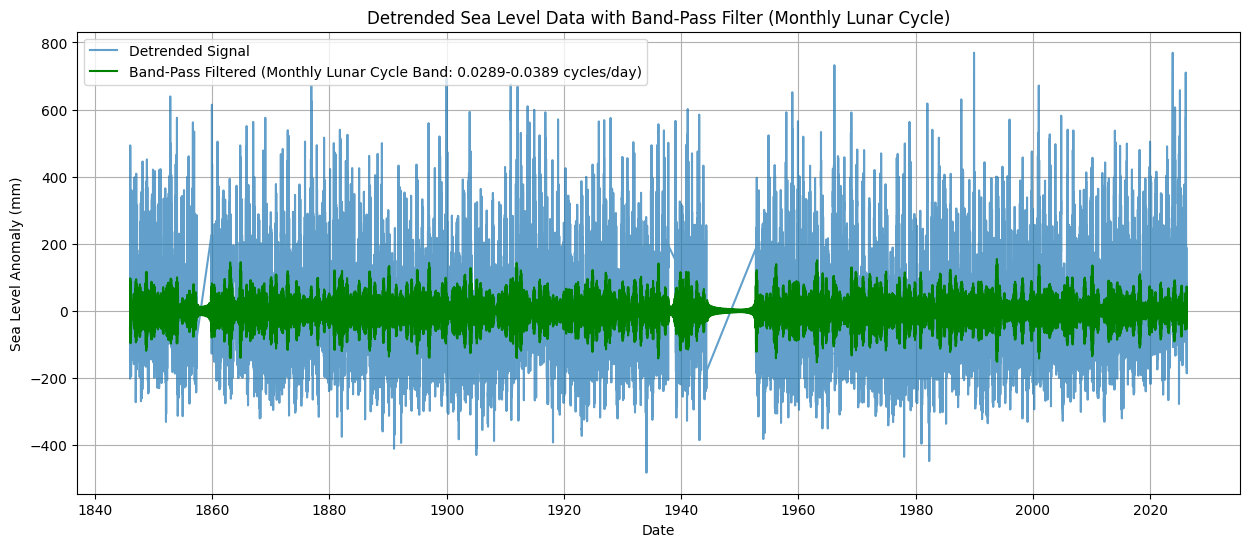

In [ ]:
# Apply a band-pass filter to isolate the monthly lunar cycle
# The monthly lunar cycle frequency is approximately 0.03386 cycles/day (1/29.53 days)
# We'll create a narrow band around this frequency.

bandpass_lower_cutoff = lunar_cycle_freq - 0.005 # A band slightly below the lunar cycle freq
bandpass_upper_cutoff = lunar_cycle_freq + 0.005 # A band slightly above the lunar cycle freq

time_filtered_bp, signal_filtered_bp = bandpass_filter(time_numeric, detrend, [bandpass_lower_cutoff, bandpass_upper_cutoff])

plt.figure(figsize=(15, 6))
plt.plot(Brest_df.index, detrend, label='Detrended Signal', alpha=0.7)
plt.plot(Brest_df.index, signal_filtered_bp, color='green', label=f'Band-Pass Filtered (Monthly Lunar Cycle Band: {bandpass_lower_cutoff:.4f}-{bandpass_upper_cutoff:.4f} cycles/day)')
plt.xlabel('Date')
plt.ylabel('Sea Level Anomaly (mm)')
plt.title('Detrended Sea Level Data with Band-Pass Filter (Monthly Lunar Cycle)')
plt.grid(True)
plt.legend()
plt.show()

Applying a high-pass filter to visualise potential diurnal tides without low-frequency signals.

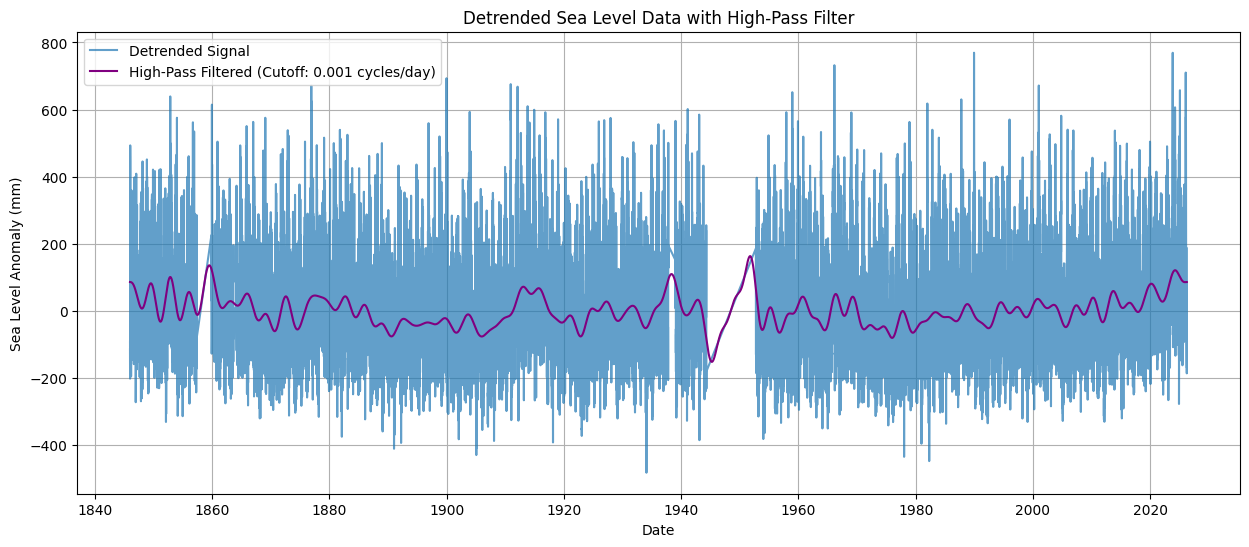

In [ ]:
# Apply a high-pass filter to the detrended signal
# We'll use a cutoff slightly above the very low frequencies (e.g., solar and nodal cycles)
# A cutoff of 0.001 cycles/day will remove frequencies below this, keeping most of the monthly and daily variations.
highpass_cutoff = 0.001 # cycles/day

time_filtered_hp, signal_filtered_hp = highpass_filter(time_numeric, detrend, highpass_cutoff)

plt.figure(figsize=(15, 6))
plt.plot(Brest_df.index, detrend, label='Detrended Signal', alpha=0.7)
plt.plot(Brest_df.index, signal_filtered_hp, color='purple', label=f'High-Pass Filtered (Cutoff: {highpass_cutoff} cycles/day)')
plt.xlabel('Date')
plt.ylabel('Sea Level Anomaly (mm)')
plt.title('Detrended Sea Level Data with High-Pass Filter')
plt.grid(True)
plt.legend()
plt.show()

The high-pass filter successfully removed the very long-period oscillations, emphasizing the shorter-term fluctuations in the detrended sea level data. This can be useful for studying daily, semi-daily, or other relatively high-frequency tidal components without the influence of long-term climate signals.

Applying another band-pass filter designed to isolate longterm solar/lunar cycles.

Applying band-pass filter for frequency range: 0.0000245 to 0.0002541 cycles/day


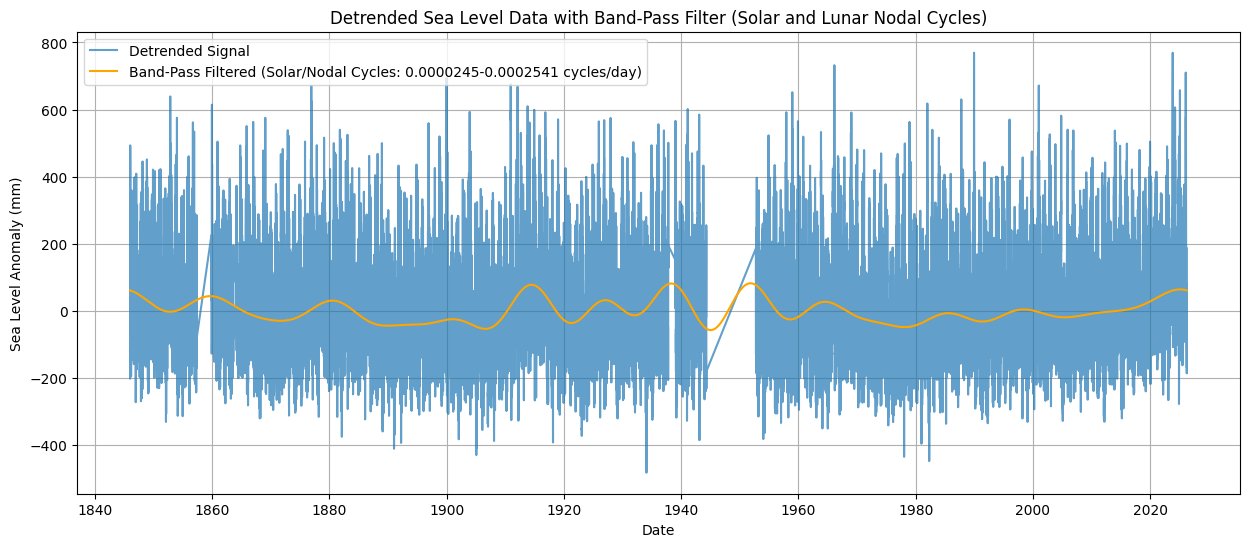

In [ ]:
# Define the band-pass cutoffs to capture the solar and lunar nodal cycles
# These frequencies are very small (cycles/day) so we need a very narrow band close to zero.
# Lower bound: slightly below the 93-year solar tidal cycle
# Upper bound: slightly above the 11-year solar cycle

bandpass_lower_nodal_solar_cutoff = solar_93yr_freq - 5e-6 # A bit below the 93-year cycle
bandpass_upper_nodal_solar_cutoff = solar_11yr_freq + 5e-6 # A bit above the 11-year cycle

print(f"Applying band-pass filter for frequency range: {bandpass_lower_nodal_solar_cutoff:.7f} to {bandpass_upper_nodal_solar_cutoff:.7f} cycles/day")

time_filtered_nodal_solar, signal_filtered_nodal_solar = bandpass_filter(time_numeric, detrend, [bandpass_lower_nodal_solar_cutoff, bandpass_upper_nodal_solar_cutoff])

plt.figure(figsize=(15, 6))
plt.plot(Brest_df.index, detrend, label='Detrended Signal', alpha=0.7)
plt.plot(Brest_df.index, signal_filtered_nodal_solar, color='orange', label=f'Band-Pass Filtered (Solar/Nodal Cycles: {bandpass_lower_nodal_solar_cutoff:.7f}-{bandpass_upper_nodal_solar_cutoff:.7f} cycles/day)')
plt.xlabel('Date')
plt.ylabel('Sea Level Anomaly (mm)')
plt.title('Detrended Sea Level Data with Band-Pass Filter (Solar and Lunar Nodal Cycles)')
plt.grid(True)
plt.legend()
plt.show()

This band-pass filter has successfully isolated the very long-period oscillations associated with the solar and lunar nodal cycles. The resulting plot shows the amplitude and phase of these combined influences over the entire record, providing a clearer view of their subtle, long-term modulations on sea level.

**Visualisation & Interpretation**

The frequency spectrum displays a prominent peak at around 0.003 cycles per day and at around the beginning of the peak. Having incorporated the signals for the 11-year Solar cycle, the 93-year Solar tidal cycle, the monthly lunar cycle, and the 18.6-year Lunar nodal cycle, we find that the 11-year, 93 year and 18.6-year cycles match up with the first dominant peak, where the monthly lunar cycle spikes at around 0.035 cycles/per day, but it does not capture a prominent peak. This could likely be a case of the decadal data shadowing over the monthly data, thus appearing like it does not match a dominant signal. Because the frequency plot tells us where to isolate and apply the differing filters, we can then isolate the necessary signals and analyse them on their own without the presence of other signals affecting the analysis.

Each of these signals that have been isolated represent differing cycles on different timescales. The first bandpass filter that has been applied aims to isolate the monthly lunar cycle from other decadal data that might have been previously masking its peak. From the plot we can observe that the amplitude of the signal is quite small, but the periods the signal are very short. This signal captures the monthly cycle of the sea level/tidal changes, showing the frequent change in amplitude from high amplitude spring tides during the full and new moons and the low-level neap tides that occur during quarter moons.

For the high pass filter, it filters out the low frequency signals, thus only showing a signal that could represent the presence of potential diurnal tides. This plot therefore shows that this cycle occurs over longer period, where its amplitude overall is also quite low meaning the impact it presents on tides in the short term may not be as significant in comparison to the monthly cycle.

Finally for the second bandpass filter, it isolates the long term solar and lunar cycles. The overall amplitude is again quite low, if not the lowest of the three plots made, showing the impact it has on short term tidal activity may be quite low but is incredibly useful for tracking the long term tidal changes. Additionally the period is also low, this cycle again occurs over longer periods which is expect of the long term solar and lunar cycles.

From these plots, we can likely determine that the the low bandpass filter, isolating the long term cycles best fits the long term tidal data as it best showcases the effect these cycles have on the sea levels in Brest, France

A limitation of using daily tide gauge data is that it can only reveal long-term sea level trends, whereas hourly tidal data allows for short-term analysis of semidiurnal and diurnal tidal cycles. Analysing specific time periods more precisely can also improve identification of the dominant frequencies within the signal. Using only daily data may have prevented lunar-related frequencies from being detected, as the Moon’s influence on tides primarily occurs on hourly timescales.

# Reflections

**Elena**

This week I was GitHub manager, ensuring everything was saved to GitHub ahead of the final submission. After copying the template repository in GitHub, I edited the header section to include a project title, everyone's roles for the week, and set out the sections for everyone to fill in their parts. As part of my role cleaning up the repository, I decided to rename the data file to be more easily reproducible, replacing commas with underscores. This had to be changed in both the GitHub and the CoLab workspaces, and I had to ensure everyone was finished working with the original file before making this change so the code on their end would still run. Once all the code was written and reflections submitted, I made the final commit to GitHub, thus completing my role.

**Sameer**

As the Data Steward for this project, a significant portion of my initial efforts involved an extensive search for appropriate datasets to facilitate a robust Fourier series analysis of tidal fluctuations. This process required sifting through various data repositories and portals to find historical sea-level measurements that met our criteria for both temporal depth and data quality.

After considerable exploration, the University of Hawaii Sea Level Center (UHSLC) portal (`https://uhslc.soest.hawaii.edu/data/`) emerged as an invaluable resource. Its comprehensive collection of long-term tidal gauge records proved ideal. The decision to focus on Brest, France, was driven by a crucial factor: the availability of continuous data spanning from 1846 to the present. This exceptionally long time series is paramount for a meaningful Fourier analysis, allowing us to identify subtle, long-period tidal constituents and assess changes in fluctuation patterns over nearly two centuries. Ensuring the integrity and consistency of this historical data, including handling any potential gaps or inconsistencies in the original raw files, was a primary responsibility during the import phase.

**Kimi**

My role in visualation and interpretation this week required me to fully grasp and  analyse the sort of code and data we are doing. Because the time series analysis content this week consisted mainly of visualation and code that made the plots, Sutton in the analysis and modelling role did all of the code instead. I primarily focused on interpreting the plots that were generated by Sutton instead, which meant i had to do some additional research into the tides and the cycles that we had chosen for the differing signals, Suttons annotations also provided some extra context needed to understand the code and the plots. I had also discovered that the data we had was different to the initial question we had asked but this was no worry as the daily data we ended up choosing ended up matching the differnt solar and lunar cycles that were chosen. Overall, this week truly strengthened my understanding in the different components of time series analysis.

**Sutton**

This week I had the role of analysis modelling which was a big learning curve for me. Outside of this course I have had very little coding experience so establishing the time series analysis was a challenge and took some time for me but I persevered and got there in the end. Undertaking this role required me to establish a time series analysis of daily tide levels in Brest, France, and look at potential signals that may match with frequency changes in the tides. For this I looked at lunar and solar cycles that would affect tidal levels due to varying gravitational forces. I also visualised the data as this was a key step in the analysis but I allowed Kimi to interpret my model and draw conclusions. Ultimately this week's project has been the most rewarding in terms of knowledge gained and sense of accomplishment.

**Cathy**

This week I was responsible to do the narrative role. Suttons clear annotations that complimented his data analysis made this role easier for me as I did not have to guess what he did. I have gotten a better understanding of how time series analysis can be used to find frequencies that can be the reasoning behind why detrended signals are the way they are by writing the markdown explainations. I was also able to note limitations in our analysis for which we may want to change if we choose this project for our portfolio, particularly the type of data and to what time frame we used to analyse the frequencies.

**Leo**

As quality control, I checked that the notebook ran top to bottom, all necessary links (data, github) worked, that the figures were correctly labelled and all the explanations made sense. While some of the interpretations were a bit of a stretch as some of the bands don't show a clear signal, we understand that this is because the data we used didn't match our original question and the ad hoc signals we were searching for probably didn't match the data either. While this is an issue concerning the quality of the science, the quality of the method is solid and the project would be reproducible. After my initial check, some changes were made to file names. These were partially accounted for in the code, but upon running a final check I saw that the code was having trouble reading in a the sheet from the excel and fixed that.